# WeylScalars

In [1]:
Needs["xAct`xCoba`", FileNameJoin[{Environment["GENERATO"], "src/Generato.wl"}]]

------------------------------------------------------------
Package xAct`xPerm`  version 1.2.3, {2015, 8, 23}
CopyRight (C) 2003-2020, Jose M. Martin-Garcia, under the General Public\
 
>   License.
Connecting to external mac executable...
Connection established.
------------------------------------------------------------
Package xAct`xTensor`  version 1.2.0, {2021, 10, 17}
CopyRight (C) 2002-2021, Jose M. Martin-Garcia, under the General Public\
 
>   License.
------------------------------------------------------------
These packages come with ABSOLUTELY NO WARRANTY; for details type\
 
>   Disclaimer[]. This is free software, and you are welcome to redistribute\
 
>   it under certain conditions. See the General Public License for details.
------------------------------------------------------------
------------------------------------------------------------
Package xAct`xCoba`  version 0.8.6, {2021, 2, 28}
CopyRight (C) 2005-2021, David Yllanes and Jose M. Martin-Garcia, under t

In [2]:
(* set mode to check equations *)
SetCheckInputEquations[True];

In [4]:
DefManifold[M3, 3, IndexRange[a, z]];

In [5]:
DefMetric[1, gam[-i, -j], cd, SymbolOfCovD -> {"|", "D"}, PrintAs -> "\[Gamma]"];

In [6]:
DefChart[cart, M3, {1, 2, 3}, {X[], Y[], Z[]}, ChartColor -> Blue];

In [7]:
<<"wl/WeylScal_vars.wl"

In [8]:
<<"wl/WeylScal_rhs.wl"

## Check Expressions

In [9]:
rhsof[var_] := Module[{}, var /. {var[[0]] :> RHSOf[ToString[var[[0]]]]}];
eqssof[varlist_] := Module[{var}, 
   Table[var = varlist[[ivar]][[1]]; var == rhsof[var]//ScreenDollarIndices, {ivar, 1, Length[varlist]}]];

### Intermediate Variables

#### Determinant of metric

-Image-
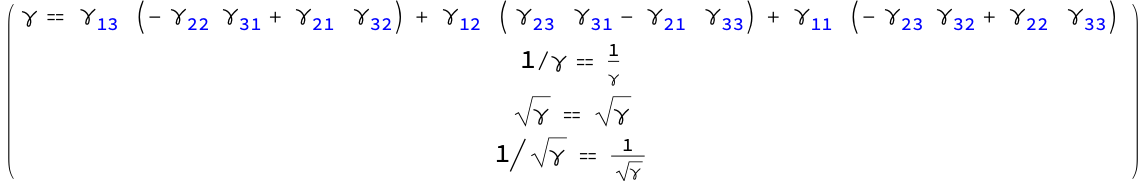

In [11]:
eqssof[IntermediateVarlist[[1;;4]]] // MatrixForm // Rasterize

#### Inverse metric $\gamma^{ij}$

-Image-
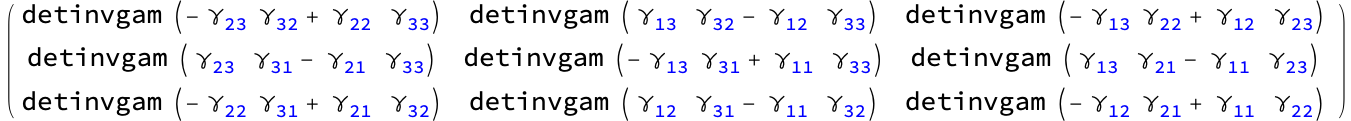

In [12]:
Table[invgam$RHS[{ii, cart}, {jj, cart}] // ToValues, {ii, 1, 3}, {jj, 1, 3}] // MatrixForm // Rasterize

#### Other intermediate variables

-Image-
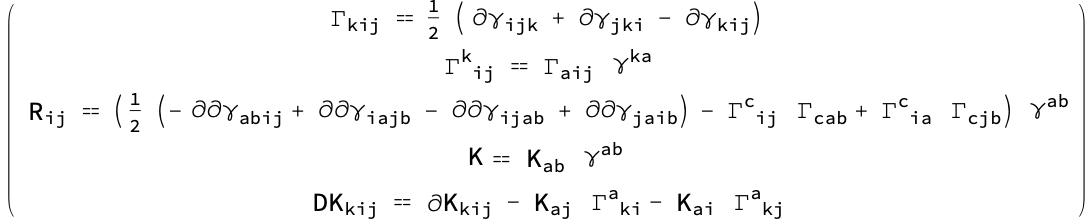

In [13]:
eqssof[IntermediateVarlist[[6;;]]] // MatrixForm // Rasterize

### Tetrad

#### 3d vectors

$$
\begin{align}
u^i
&=(-y, x, 0),
\\
v^i
&=(x, y, z),
\\
w^i
&=\gamma^{ij}\epsilon_{jkl}u^kv^l,
\end{align}
$$

{-Y[], X[], 0}
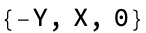

In [14]:
Table[uvec$RHS[{ii, cart}] // ToValues, {ii, 1, 3}]

{X[], Y[], Z[]}
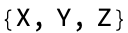

In [15]:
Table[vvec$RHS[{ii, cart}] // ToValues, {ii, 1, 3}]

-Image-
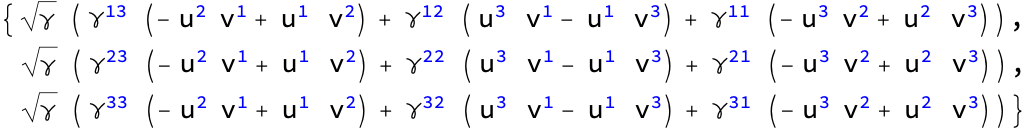

In [16]:
Table[wvec$RHS[{ii, cart}] // DummyToBasis[cart] // TraceBasisDummy // ToValues, {ii, 1, 3}] // Simplify // Rasterize

-Image-
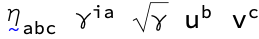

In [17]:
wvec$RHS[i] // ScreenDollarIndices // Rasterize

#### Gram-Schmidt orthonormalization

-Image-
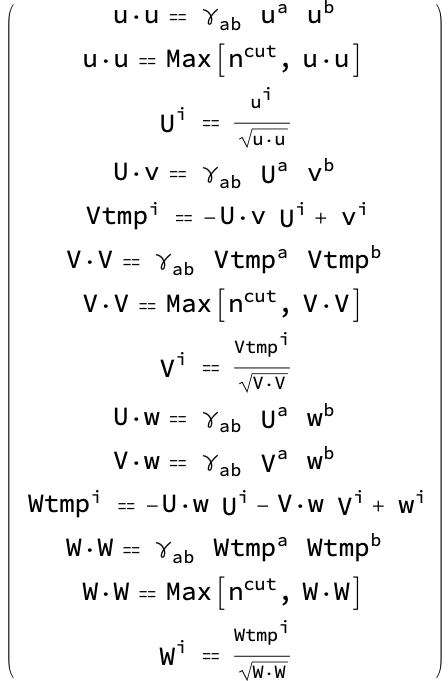

In [18]:
Rasterize[eqssof[TetradVarlist[[4;;-3]]]//MatrixForm]

#### Tetrad vectors

$$
\begin{align}
m^i
&=\frac{1}{\sqrt{2}}
\left(
W^i+i\,U^i
\right),
\\
\bar{m}^i
&=\frac{1}{\sqrt{2}}
\left(
W^i-i\,U^i
\right).
\end{align}
$$

-Image-
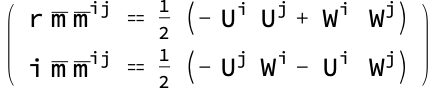

In [19]:
eqssof[TetradVarlist[[-2;;-1]]] // MatrixForm // Rasterize

### Use $E_{ij}$ and $B_{ij}$

-Image-
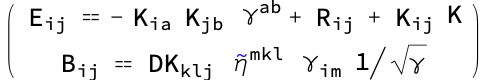

In [20]:
eqssof[EBVarlist] // MatrixForm // Rasterize

-Image-
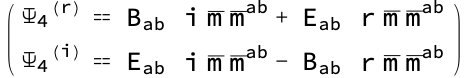

In [21]:
eqssof[Psi4Varlist] // MatrixForm // Rasterize

### Use Gauss-Codazzi

-Image-
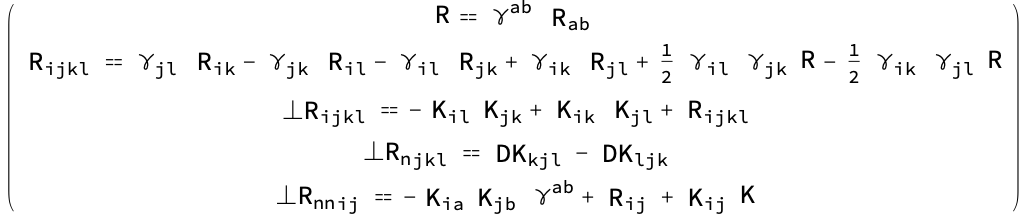

In [22]:
eqssof[GaussCodazziVarlist] // MatrixForm // Rasterize

-Image-
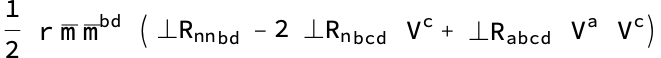

In [23]:
Psi4realGaussCodazzi$RHS[] // ScreenDollarIndices // Rasterize

-Image-
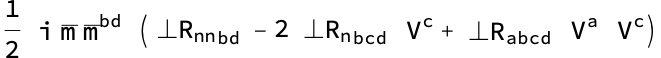

In [24]:
Psi4imagGaussCodazzi$RHS[] // ScreenDollarIndices // Rasterize